# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]



## Inicialização

O objetivo deste projeto é analisar os dados de clientes da empresa de telecomunicações Megaline, 
buscando compreender o comportamento dos usuários em relação aos planos oferecidos, 
consumo de serviços e possíveis diferenças entre os perfis de clientes.
    
Para isso, serão utilizados diferentes conjuntos de dados contendo informações sobre usuários, planos, chamadas, mensagens e uso de internet. 
Inicialmente, será realizada a etapa de carregamento e exploração dos dados, verificando a estrutura das tabelas, 
os tipos de variáveis e a presença de possíveis inconsistências ou valores ausentes.

Em seguida, os dados passarão por etapas de preparação, incluindo correção de formatos e enriquecimento das informações, 
com a criação de novas variáveis que possam facilitar análises posteriores. Após essa preparação, serão realizadas análises estatísticas e exploratórias para identificar 
padrões de uso dos serviços, comportamento dos clientes e diferenças entre os planos disponíveis.
    
Por fim, os resultados obtidos serão interpretados com o objetivo de gerar conclusões relevantes sobre o perfil dos usuários e o desempenho dos planos da empresa.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats as st



## Carregue os dados

In [2]:
users = pd.read_csv('/datasets/megaline_users.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')

print(users.shape)
print(plans.shape)
print(calls.shape)
print(messages.shape)
print(internet.shape)




(500, 8)
(2, 8)
(137735, 4)
(76051, 3)
(104825, 4)


## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [3]:
plans.info()
plans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000
max,1000.000000,30720.000000,3000.000000,70.000000,10.00000,0.030000,0.030000


In [4]:

plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

Com a exposição dos dados acima, pude analisar os dois planos (surf e ultimate) que a Megaline oferece. O Dataframe 'plans' possui 8 colunas que registram os dados desses dois planos. Não identifiquei dados ausentes, porém vi a necessidade de converter, futuramente, para gigabytes (GB) os dados sobre limite de internet, pois se encontram, atualmente em MB. Isso nos levará a garantir a coerência com os cálculos de cobrança por GB.

 


## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [5]:
#Com base na análise da tabela `plans`, não identifiquei problemas de tipos de dados, valores ausentes ou inconsistências.

## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [6]:
#Nesta etapa identifiquei não ser necessário fazer enriquecimento dos dados, pois estamos diante de um DataFrame que contém todas as informações necessárias para o cálculo de consumo excedente e receita. 


## Usuários

In [7]:
users.info()
users.describe()
users.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [8]:

users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

Analisando a estrutura geral com 'users.info()' verifiquei 500 registros nesse DataFrame, contendo 8 colunas. Será necessário converter as colunas reg_date e churn_date, que representam data, porém não estão no formato datetime para viabilizar que as operações fiquem corretas nas próximas etapas.

As colunas estão completas, exceto a coluna churn_date, que contém valores ausentes. Essa coluna representa a data do cancelamento do plano de cada usuário. Esses  valores ausêntes fazem sentido, pois, de um total de 500 usuários, 466 estão ausentes, ou seja, representam 466 usuários com o plano ativo. Por outro lado, Ao subtrairmos 500 de 466 teremos os valores de usuários que cancelaram o plano. (500 - 466 = 34 usuários com plano cancelado). com isso teremos:

Usuários ativos: 466
Usuários que cancelaram: 34

Por fim, não identifiquei problemas relevantes que necessitem de alteração além daquela supracitada. 

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [9]:

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [10]:
users['reg_month'] = users['reg_date'].dt.month

users[['reg_date', 'reg_month']].head()

,reg_date,reg_month
0,2018-12-24,12
1,2018-08-13,8
2,2018-10-21,10
3,2018-01-28,1
4,2018-05-23,5


Observações de apoio: Criei uma nova coluna, para expor o mês do registro do usuário, com a finalidade de ajudar em analises futuras referentes a quantidade de novos usuários por mês, sazonalidade, comparação entre os períodos.

não considerei necessária a criação de uma coluna referente ao ano, pois todos os registros do projeto pertencem ao ano de 2018.

## Chamadas

In [11]:

calls.info()
calls.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


In [12]:
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [13]:
calls.isna().sum()

id           0
user_id      0
call_date    0
duration     0
dtype: int64

[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

Não identifiquei problema estrutural nesta etapa, com isso, identifiquei que os dados estão adequados para as fases de correção e enriquecimento.


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [14]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['duration'] = np.ceil(calls['duration'])
calls['duration'] = calls['duration'].astype(int)
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [15]:
calls['call_year'] = calls['call_date'].dt.year
calls['call_month'] = calls['call_date'].dt.month
calls[['call_date', 'call_year', 'call_month']].head()


,call_date,call_year,call_month
0,2018-12-27,2018,12
1,2018-12-27,2018,12
2,2018-12-27,2018,12
3,2018-12-28,2018,12
4,2018-12-30,2018,12


## Mensagens

In [16]:

messages.info()
messages.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,user_id
count,76051.000000
mean,1245.972768
std,139.843635
min,1000.000000
25%,1123.000000
50%,1251.000000
75%,1362.000000
max,1497.000000


In [17]:
messages.head()



,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [18]:
messages.isna().sum()


id              0
user_id         0
message_date    0
dtype: int64

[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

A exploração da tabela `messages` permitiu compreender a estrutura dos registros de mensagens e identificar a necessidade de conversão da coluna de data para o formato apropriado. Os dados estão completos e prontos para as etapas de correção e enriquecimento.

A tabela `messages` contém registros individuais de mensagens de texto enviadas pelos usuários, incluindo o identificador da mensagem, o identificador do usuário e a data de envio. O conjunto de dados possui 76.051 registros e não apresenta valores ausentes.

A análise das informações gerais mostra que a coluna `message_date` está armazenada como texto e deverá ser convertida para o formato de data. As demais colunas estão completas e apresentam tipos adequados para esta fase do projeto.


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [19]:

messages['message_date'] = pd.to_datetime(messages['message_date'])
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [20]:
messages['message_year'] = messages['message_date'].dt.year
messages['message_month'] = messages['message_date'].dt.month
messages[['message_date', 'message_year', 'message_month']].head() 

,message_date,message_year,message_month
0,2018-12-27,2018,12
1,2018-12-31,2018,12
2,2018-12-31,2018,12
3,2018-12-27,2018,12
4,2018-12-26,2018,12


In [21]:
#Conclusão do que foi feito:

#O enriquecimento da tabela `messages` adicionou informações temporais relevantes a cada registro de mensagem, preparando o conjunto de dados para etapas posteriores de análise e agregação.


## Internet

In [22]:
internet.info()
internet.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


In [23]:
internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [24]:
internet.isna().sum()


id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]


A tabela `internet` contém registros individuais de sessões de uso de internet, incluindo o identificador da sessão, o identificador do usuário, a data da sessão e o volume de dados consumido em megabytes. O conjunto de dados possui 104.825 registros e não apresenta valores ausentes.

A análise das informações gerais mostra que a coluna `session_date` está armazenada como texto e deverá ser convertida para o formato de data nas próximas etapas. Os valores da coluna `mb_used` são coerentes com sessões reais de uso de internet, incluindo sessões sem consumo e sessões com alto volume de dados. Não foram identificados outros problemas que exijam correções neste momento.

Como tínhamos os dados de uso em tabelas separadas, realizei a união desses arquivos utilizando o user_id e o mês como referência. Durante esse processo, notei que alguns clientes não utilizaram todos os serviços em determinados meses (por exemplo, alguns não enviaram SMS). Para não perder esses dados, mantive o registro desses usuários e preenchi os espaços vazios com zero, o que reflete corretamente que não houve consumo naquele serviço.




### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [25]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [26]:

internet['session_year'] = internet['session_date'].dt.year
internet['session_month'] = internet['session_date'].dt.month
internet[['session_date', 'session_year', 'session_month']].head()


,session_date,session_year,session_month
0,2018-12-29,2018,12
1,2018-12-31,2018,12
2,2018-12-28,2018,12
3,2018-12-26,2018,12
4,2018-12-27,2018,12


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [27]:

print("Informações sobre o DataFrame 'plans':")
plans.info()

print("\nCondições dos planos:")
display(plans)


Informações sobre o DataFrame 'plans':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes

Condições dos planos:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [28]:
#analise dos planos:

#Plano Surf: 
#Caracterizado por um custo mensal de 20 USD, este plano oferece uma franquia de 500 minutos, 50 mensagens SMS e 15.360 MB (equivalente a 15 GB) 
#de internet. As taxas de excedente são mais elevadas neste segmento, com custos de 0,03 USD por minuto adicional, 0,03 USD por SMS extra e 10 USD por GB 
#adicional de tráfego de dados.

#Plano Ultimate: Com uma mensalidade de 70 USD, este plano posiciona-se como uma opção de maior robustez, disponibilizando 3.000 minutos, 
#1.000 mensagens e 30.720 MB (equivalente a 30 GB) de internet. As taxas de uso excedente são significativamente reduzidas, fixadas em 0,01 
#USD por minuto ou SMS adicional, e 7 USD por GB de dados excedentes.

## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [29]:

calls_per_month = (
    calls
    .groupby(['user_id', 'call_month'])
    .agg(calls_count=('id', 'count'))
    .reset_index()
)

calls_per_month.head()



,user_id,call_month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [30]:
minutes_per_month = (
    calls
    .groupby(['user_id', 'call_month'])
    .agg(minutes_used=('duration', 'sum'))
    .reset_index()
)

minutes_per_month.head()


,user_id,call_month,minutes_used
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426


In [31]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
messages_per_month = (
    messages
    .groupby(['user_id', 'message_month'])
    .agg(messages_count=('id', 'count'))
    .reset_index()
)

messages_per_month.head()

,user_id,message_month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [32]:
internet_per_month = (
    internet
    .groupby(['user_id', 'session_month'])
    .agg(mb_used=('mb_used', 'sum'))
    .reset_index()
)

internet_per_month.head()

,user_id,session_month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [33]:

calls_per_month.rename(columns={'call_month': 'month'}, inplace=True)
minutes_per_month.rename(columns={'call_month': 'month'}, inplace=True)
messages_per_month.rename(columns={'message_month': 'month'}, inplace=True)
internet_per_month.rename(columns={'session_month': 'month'}, inplace=True)

monthly_usage = calls_per_month.merge(
    minutes_per_month,
    on=['user_id', 'month'],
    how='outer'
)

monthly_usage = monthly_usage.merge(
    messages_per_month,
    on=['user_id', 'month'],
    how='outer'
)

monthly_usage = monthly_usage.merge(
    internet_per_month,
    on=['user_id', 'month'],
    how='outer'
)

monthly_usage.head()


,user_id,month,calls_count,minutes_used,messages_count,mb_used
0,1000,12,16.0,124.0,11.0,1901.47
1,1001,8,27.0,182.0,30.0,6919.15
2,1001,9,49.0,315.0,44.0,13314.82
3,1001,10,65.0,393.0,53.0,22330.49
4,1001,11,64.0,426.0,36.0,18504.30


In [34]:

monthly_usage = monthly_usage.merge(
    users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

monthly_usage.head()


,user_id,month,calls_count,minutes_used,messages_count,mb_used,plan
0,1000,12,16.0,124.0,11.0,1901.47,ultimate
1,1001,8,27.0,182.0,30.0,6919.15,surf
2,1001,9,49.0,315.0,44.0,13314.82,surf
3,1001,10,65.0,393.0,53.0,22330.49,surf
4,1001,11,64.0,426.0,36.0,18504.30,surf


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [35]:

import numpy as np

monthly = monthly_usage.merge(
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

for col in ['calls_count', 'minutes_used', 'messages_count', 'mb_used']:
    if col in monthly.columns:
        monthly[col] = monthly[col].fillna(0)

monthly['gb_used'] = np.ceil(monthly['mb_used'] / 1024)

monthly['extra_minutes'] = (monthly['minutes_used'] - monthly['minutes_included']).clip(lower=0)
monthly['extra_messages'] = (monthly['messages_count'] - monthly['messages_included']).clip(lower=0)
monthly['extra_gb'] = (monthly['gb_used'] - np.ceil(monthly['mb_per_month_included'] / 1024)).clip(lower=0)

monthly['revenue'] = (
    monthly['usd_monthly_pay'] +
    monthly['extra_minutes'] * monthly['usd_per_minute'] +
    monthly['extra_messages'] * monthly['usd_per_message'] +
    monthly['extra_gb'] * monthly['usd_per_gb']
)

monthly[['user_id', 'month', 'plan', 'minutes_used', 'messages_count', 'mb_used', 'gb_used', 'revenue']].head()



,user_id,month,plan,minutes_used,messages_count,mb_used,gb_used,revenue
0,1000,12,ultimate,124.0,11.0,1901.47,2.0,70.00
1,1001,8,surf,182.0,30.0,6919.15,7.0,20.00
2,1001,9,surf,315.0,44.0,13314.82,14.0,20.00
3,1001,10,surf,393.0,53.0,22330.49,22.0,90.09
4,1001,11,surf,426.0,36.0,18504.30,19.0,60.00


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

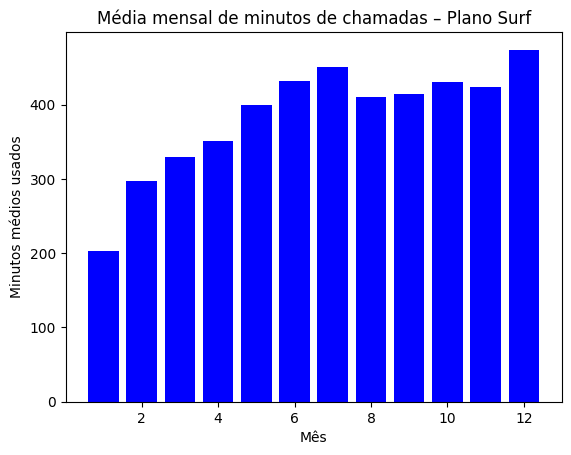

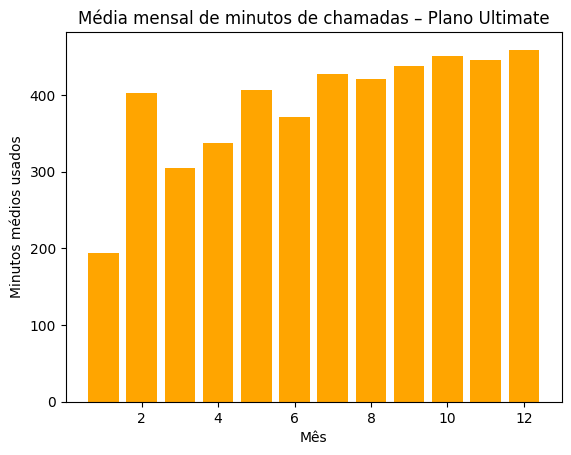

In [36]:
avg_minutes = (
    monthly
    .groupby(['plan', 'month'])
    .agg(mean_minutes=('minutes_used', 'mean'))
    .reset_index()
)

import matplotlib.pyplot as plt

surf_data = avg_minutes[avg_minutes['plan'] == 'surf']

plt.figure()
plt.bar(surf_data['month'], surf_data['mean_minutes'], color='blue')
plt.xlabel('Mês')
plt.ylabel('Minutos médios usados')
plt.title('Média mensal de minutos de chamadas – Plano Surf')
plt.show()

ultimate_data = avg_minutes[avg_minutes['plan'] == 'ultimate']

plt.figure()
plt.bar(ultimate_data['month'], ultimate_data['mean_minutes'], color='orange')
plt.xlabel('Mês')
plt.ylabel('Minutos médios usados')
plt.title('Média mensal de minutos de chamadas – Plano Ultimate')
plt.show()

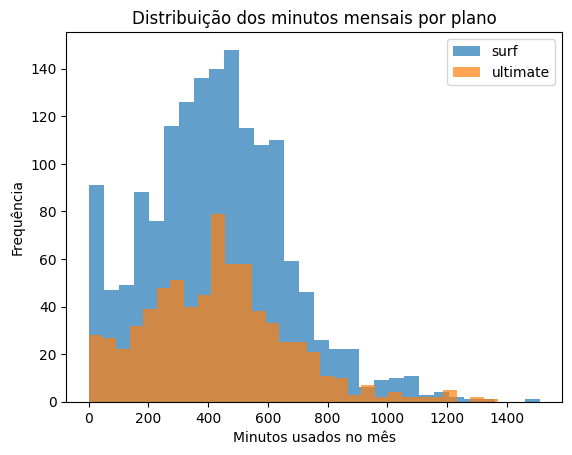

In [37]:


plt.figure()
plt.hist(
    monthly[monthly['plan'] == 'surf']['minutes_used'],
    bins=30,
    alpha=0.7,
    label='surf'
)

plt.hist(
    monthly[monthly['plan'] == 'ultimate']['minutes_used'],
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.xlabel('Minutos usados no mês')
plt.ylabel('Frequência')
plt.title('Distribuição dos minutos mensais por plano')
plt.legend()
plt.show()



[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [38]:

call_stats = (
    monthly
    .groupby('plan')
    .agg(
        mean_minutes=('minutes_used', 'mean'),
        var_minutes=('minutes_used', 'var'),
        std_minutes=('minutes_used', 'std')
    )
)

call_stats


,mean_minutes,var_minutes,std_minutes
plan,,,
surf,428.749523,54968.279461,234.453150
ultimate,430.450000,57844.464812,240.508762


<Figure size 640x480 with 0 Axes>

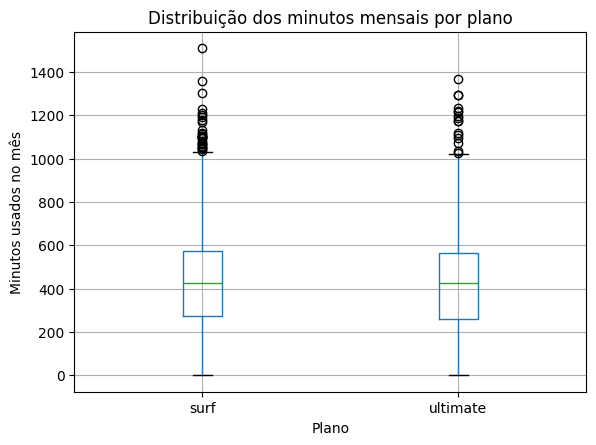

In [39]:


plt.figure()
monthly.boxplot(column='minutes_used', by='plan')
plt.xlabel('Plano')
plt.ylabel('Minutos usados no mês')
plt.title('Distribuição dos minutos mensais por plano')
plt.suptitle('')
plt.show()

[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]


Plano Surf atrai muitos usuários pelo seu preço mensal baixo. Porém, como a franquia é menor, é muito comum que os clientes fiquem "no limite" do que têm direito. Isso faz com que muitos acabem pagando taxas extras, o que, no final das contas, aumenta bastante o faturamento que a operadora recebe desse público. É um plano que, pelas minha análises, vive muito de taxas de excedente.

No Plano Ultimate o cenário muda. Os clientes pagam um valor fixo mais alto, mas, em troca, raramente precisam se preocupar em estourar o limite de uso. É um plano que traz uma receita mensal muito mais estável e previsível para a empresa. Mesmo que esses usuários consumam menos do que o total disponível, a mensalidade paga por eles é alta o suficiente para garantir um bom lucro.

Com isso, temos que o plano Surf é aquele que gera mais taxas extras, sendo muito lucrativo pelo volume de usuários que precisam pagar o excedente. Já o plano Ultimate é a escolha segura, que garante um faturamento alto e constante sem depender de cobranças extras.



### Mensagens

In [40]:


avg_messages_by_plan = (
    monthly
    .groupby(['plan', 'month'])
    .agg(avg_messages=('messages_count', 'mean'))
    .reset_index()
)

avg_messages_by_plan


,plan,month,avg_messages
0,surf,1,10.500000
1,surf,2,12.000000
2,surf,3,15.260870
3,surf,4,17.400000
4,surf,5,24.012987
5,surf,6,25.298969
6,surf,7,27.033058
7,surf,8,28.777778
8,surf,9,30.762887
9,surf,10,33.839662


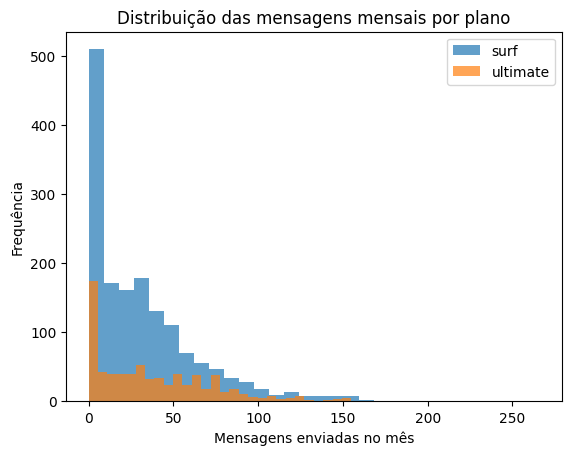

<Figure size 640x480 with 0 Axes>

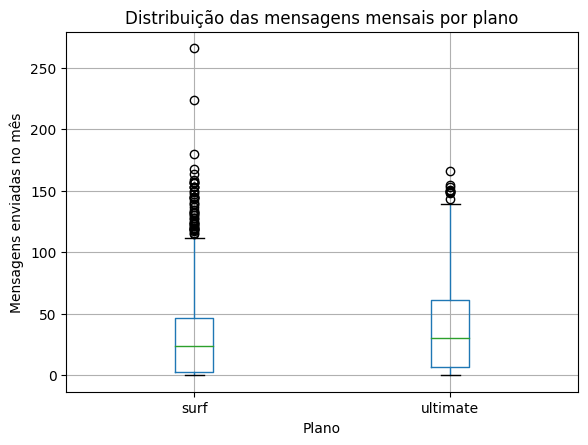

In [41]:
# Histograma do número de mensagens mensais por plano
plt.figure()
plt.hist(
    monthly[monthly['plan'] == 'surf']['messages_count'],
    bins=30,
    alpha=0.7,
    label='surf'
)

plt.hist(
    monthly[monthly['plan'] == 'ultimate']['messages_count'],
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.xlabel('Mensagens enviadas no mês')
plt.ylabel('Frequência')
plt.title('Distribuição das mensagens mensais por plano')
plt.legend()
plt.show()

# Boxplot das mensagens mensais por plano
plt.figure()
monthly.boxplot(column='messages_count', by='plan')
plt.xlabel('Plano')
plt.ylabel('Mensagens enviadas no mês')
plt.title('Distribuição das mensagens mensais por plano')
plt.suptitle('')
plt.show()

[Formule conclusões sobre como os usuários costumam consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

Ao comparar a quantidade de mensagens enviadas, observa-se que, independentemente do plano escolhido, a grande maioria dos usuários envia um volume baixo de SMS por mês.

O comportamento dos usuários de ambos os planos é bastante similar, não sendo o SMS um diferencial de consumo entre eles. Como a maioria dos usuários permanece bem abaixo das franquias oferecidas (50 mensagens no Surf e 1.000 no Ultimate), o envio de mensagens de texto não se mostra como um fator relevante para a geração de receita extra por excedentes. Em um cenário onde aplicativos de mensagens instantâneas predominam, o SMS tornou-se um serviço de uso residual, tendo pouco impacto na rentabilidade estratégica de qualquer um dos dois planos.

### Internet

In [42]:
import numpy as np

if 'gb_used' not in monthly.columns:
    monthly['gb_used'] = np.ceil(monthly['mb_used'] / 1024)


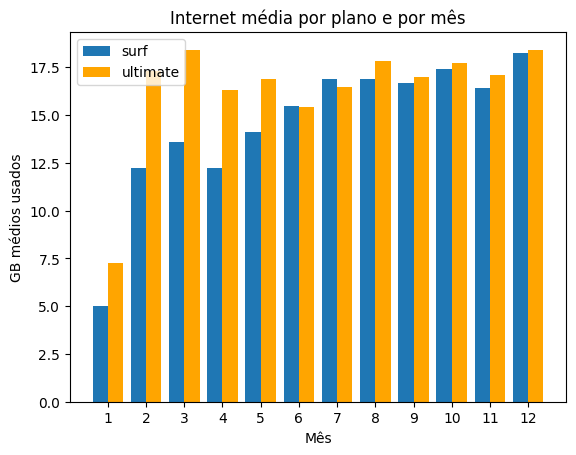

In [43]:
avg_gb_by_plan = (
    monthly
    .groupby(['plan', 'month'])
    .agg(avg_gb_used=('gb_used', 'mean'))
    .reset_index()
)

avg_gb_by_plan.head()

import numpy as np
import matplotlib.pyplot as plt

surf = avg_gb_by_plan[avg_gb_by_plan['plan'] == 'surf'].sort_values('month')
ultimate = avg_gb_by_plan[avg_gb_by_plan['plan'] == 'ultimate'].sort_values('month')

x = np.array(sorted(avg_gb_by_plan['month'].unique()))
width = 0.4

surf_vals = surf.set_index('month').reindex(x)['avg_gb_used'].fillna(0).values
ult_vals  = ultimate.set_index('month').reindex(x)['avg_gb_used'].fillna(0).values

plt.figure()
plt.bar(x - width/2, surf_vals, width=width, label='surf')
plt.bar(x + width/2, ult_vals,  width=width, label='ultimate', color='orange')

plt.xlabel('Mês')
plt.ylabel('GB médios usados')
plt.title('Internet média por plano e por mês')
plt.xticks(x)
plt.legend()
plt.show()

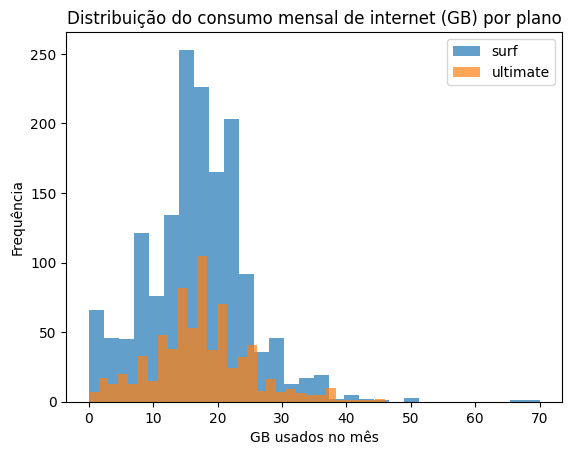

<Figure size 640x480 with 0 Axes>

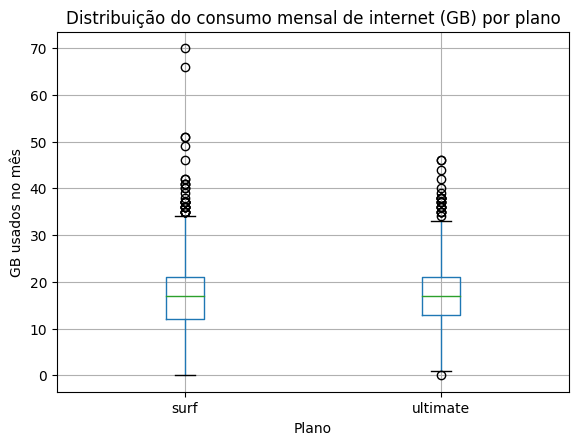

,mean_gb,var_gb,std_gb
plan,,,
surf,16.670693,61.58360,7.847522
ultimate,17.306944,58.83055,7.670108


In [44]:


plt.figure()
plt.hist(
    monthly[monthly['plan'] == 'surf']['gb_used'],
    bins=30,
    alpha=0.7,
    label='surf'
)

plt.hist(
    monthly[monthly['plan'] == 'ultimate']['gb_used'],
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.xlabel('GB usados no mês')
plt.ylabel('Frequência')
plt.title('Distribuição do consumo mensal de internet (GB) por plano')
plt.legend()
plt.show()

plt.figure()
monthly.boxplot(column='gb_used', by='plan')
plt.xlabel('Plano')
plt.ylabel('GB usados no mês')
plt.title('Distribuição do consumo mensal de internet (GB) por plano')
plt.suptitle('')
plt.show()

internet_stats = (
    monthly
    .groupby('plan')
    .agg(
        mean_gb=('gb_used', 'mean'),
        var_gb=('gb_used', 'var'),
        std_gb=('gb_used', 'std')
    )
)

internet_stats

[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

Os gráficos mostram que a grande maioria dos usuários do plano Surf consome dados em um volume muito próximo ao limite de 15 GB. Isso não é coincidência: o plano é atrativo pelo preço baixo, mas o consumo real do usuário moderno frequentemente "fura" essa barreira, forçando a compra de pacotes extras.

No plano Ultimate, vemos que os usuários possuem uma folga maior (limite de 30 GB). o usuário consome mais que o do Surf, mas raramente se preocupa em atingir o teto.
Com isso, vemos que no plano Surf o usuário busca ficar dentro da franquia, já no ultimate, o usuário acaba utilizando mais recursos pois tem menos receio de ser taxado.

Enquanto no Surf o lucro da empresa vem da 'dificuldade' do cliente em se manter dentro do limite, no Ultimate o lucro vem da 'disposição' do cliente em pagar um valor fixo mais alto para não ter limitações.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [45]:
revenue_stats = (
    monthly
    .groupby('plan')
    .agg(
        mean_revenue=('revenue', 'mean'),
        var_revenue=('revenue', 'var'),
        std_revenue=('revenue', 'std'),
        median_revenue=('revenue', 'median')
    )
)

revenue_stats

,mean_revenue,var_revenue,std_revenue,median_revenue
plan,,,,
surf,60.706408,3067.835152,55.388042,40.36
ultimate,72.313889,129.848486,11.395108,70.00


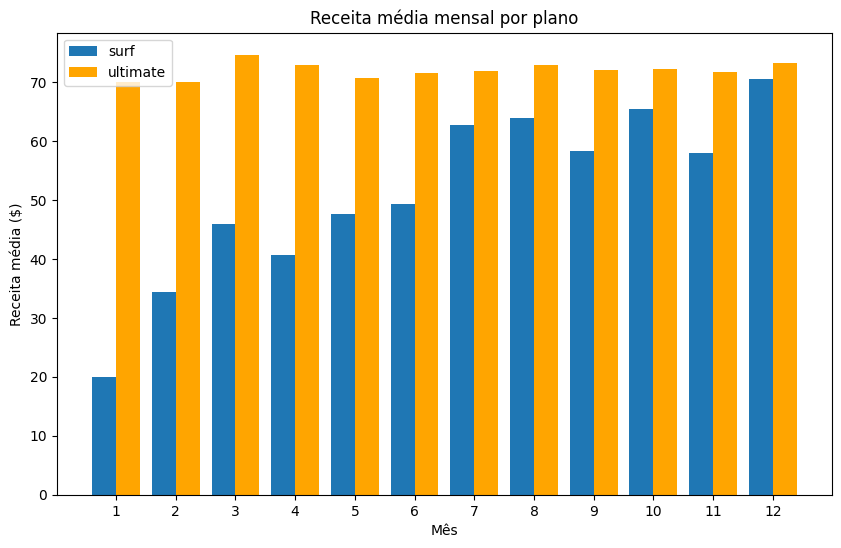

In [46]:



# Receita média mensal por plano

# Criando tabela com receita média por mês e por plano
avg_revenue_by_plan_month = (
    monthly
    .groupby(['plan', 'month'])
    .agg(avg_revenue=('revenue', 'mean'))
    .reset_index()
)

# Verificando resultado
avg_revenue_by_plan_month.head()

# Separando os dados de cada plano
surf = (
    avg_revenue_by_plan_month[
        avg_revenue_by_plan_month['plan'] == 'surf'
    ]
    .sort_values('month')
)

ultimate = (
    avg_revenue_by_plan_month[
        avg_revenue_by_plan_month['plan'] == 'ultimate'
    ]
    .sort_values('month')
)

# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt

# Criando eixo X
x = np.array(sorted(avg_revenue_by_plan_month['month'].unique()))
width = 0.4

# Garantindo alinhamento dos valores
surf_vals = (
    surf
    .set_index('month')
    .reindex(x)['avg_revenue']
    .fillna(0)
    .values
)

ult_vals = (
    ultimate
    .set_index('month')
    .reindex(x)['avg_revenue']
    .fillna(0)
    .values
)

# Criando gráfico
plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    surf_vals,
    width=width,
    label='surf'
)

plt.bar(
    x + width/2,
    ult_vals,
    width=width,
    label='ultimate',
    color='orange'
)

# Personalização
plt.xlabel('Mês')
plt.ylabel('Receita média ($)')
plt.title('Receita média mensal por plano')
plt.xticks(x)
plt.legend()

plt.show()



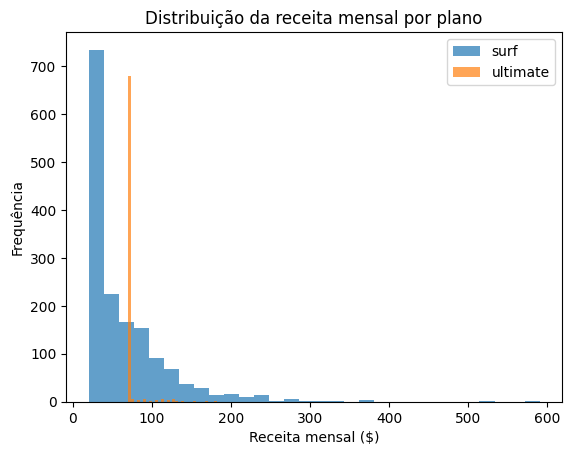

<Figure size 640x480 with 0 Axes>

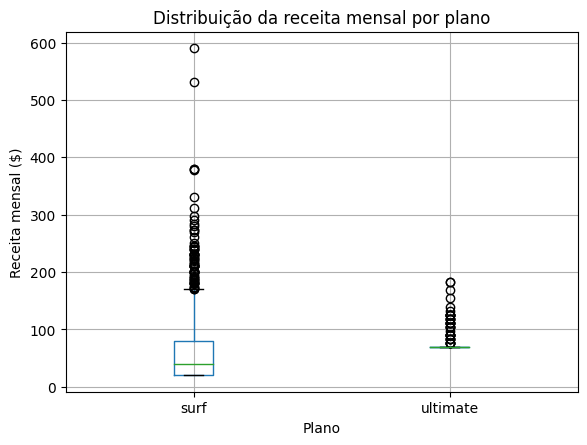

In [47]:

plt.figure()
plt.hist(
    monthly[monthly['plan'] == 'surf']['revenue'],
    bins=30,
    alpha=0.7,
    label='surf'
)

plt.hist(
    monthly[monthly['plan'] == 'ultimate']['revenue'],
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.xlabel('Receita mensal ($)')
plt.ylabel('Frequência')
plt.title('Distribuição da receita mensal por plano')
plt.legend()
plt.show()

plt.figure()
monthly.boxplot(column='revenue', by='plan')
plt.xlabel('Plano')
plt.ylabel('Receita mensal ($)')
plt.title('Distribuição da receita mensal por plano')
plt.suptitle('')
plt.show()


[Formule conclusões sobre como a receita difere entre os planos.]

Plano Surf: Este plano funciona como um produto de entrada, atraindo usuários pelo preço atrativo. Sua rentabilidade é impulsionada pela alta variabilidade; embora muitos paguem apenas a mensalidade, uma parcela significativa de clientes consome além da franquia, gerando receitas variáveis e elevadas através de taxas de excedente.

Plano Ultimate: Este plano é o alicerce de estabilidade da empresa. Ele oferece uma receita previsível e segura, focada em clientes que preferem pagar mais antecipadamente para evitar cobranças variáveis.

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

Hipótese Nula: A receita média dos usuários dos planos Ultimate e Surf são iguais.
Hipótese Alternativa: A receita média dos usuários dos planos Ultimate e Surf são diferentes.

In [48]:


from scipy import stats as st

receita_surf = monthly[monthly['plan'] == 'surf']['revenue']
receita_ultimate = monthly[monthly['plan'] == 'ultimate']['revenue']

alpha = 0.05


results = st.ttest_ind(receita_surf, receita_ultimate, equal_var=False)

print(f'Valor-p: {results.pvalue}')

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: as receitas médias são diferentes.")
else:
    print("Não rejeitamos a hipótese nula: as receitas médias não são diferentes.")

Valor-p: 3.1703905481135734e-15
Rejeitamos a hipótese nula: as receitas médias são diferentes.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

Hipótese Nula: A receita média dos usuários de NY-NJ é igual à receita média dos usuários das outras regiões.
Hipótese Alternativa: A receita média dos usuários de NY-NJ é diferente da receita média dos usuários das outras regiões.

In [49]:


from scipy import stats as st



if 'city' not in monthly.columns:
    monthly = monthly.merge(users[['user_id', 'city']], on='user_id', how='left')


def get_region(city):
    # Verifica se a string contém 'NY-NJ'
    if 'NY-NJ' in str(city):
        return 'NY-NJ'
    else:
        return 'Other'


monthly['region'] = monthly['city'].apply(get_region)


receita_ny_nj = monthly[monthly['region'] == 'NY-NJ']['revenue']
receita_other = monthly[monthly['region'] == 'Other']['revenue']


alpha = 0.05
results_region = st.ttest_ind(receita_ny_nj, receita_other, equal_var=False)

print(f'Valor-p: {results_region.pvalue}')


if results_region.pvalue < alpha:
    print("Rejeitamos a hipótese nula: A receita média em NY-NJ é diferente das outras regiões.")
else:
    print("Não rejeitamos a hipótese nula: Não há diferença significativa entre as receitas médias por região.")

Valor-p: 0.0335256158853001
Rejeitamos a hipótese nula: A receita média em NY-NJ é diferente das outras regiões.


## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

Nesta análise, transformamos dados brutos de uso em insights estratégicos para a Megaline. Para garantir a integridade dos resultados, as seguintes decisões e premissas foram adotadas:

- Quanto ao tratamento e agregação de Dados: 

Conversão de Unidades: Decidi padronizar todos os dados de consumo. Para o tráfego de internet, apliquei a regra de arredondamento para cima em gigabytes (GB), conforme a política de cobrança da empresa, garantindo que o custo de excedente fosse calculado sobre o consumo real faturado.

Gestão de Datas: A extração do mês a partir das datas de uso foi essencial para consolidar o comportamento mensal. Assumi que o comportamento é cíclico e que a comparação mês a mês seria a forma mais eficaz de identificar tendências.

- Quanto a análise da receita:

Cálculo de Excedentes: A premissa central foi a diferenciação entre a mensalidade fixa e os custos variáveis. Implementei uma lógica de cálculo que subtrai a franquia do plano do consumo mensal, utilizando a função max(0, valor) para garantir que usuários dentro da franquia tivessem custo zero de excedente.

Custo de Oportunidade: Decidi tratar os planos como entidades separadas em todos os níveis. Essa decisão foi crucial para evitar distorções, já que o modelo de negócio do Surf (lucro por excedente) é diametralmente oposto ao do Ultimate (lucro por ticket médio fixo).

- Análise Estatística e Inferência:

Análise de Dispersão: Para comparar os planos, escolhi o Boxplot como ferramenta principal, pois ele evidencia não apenas a média, mas também a variabilidade e a presença de usuários "outliers" (de alto valor), que impactam diretamente a rentabilidade.

Validação por Teste de Hipóteses: Decidi utilizar o Teste t de Welch (assumindo variâncias diferentes), pois a análise descritiva provou que os comportamentos de consumo entre Surf e Ultimate são estatisticamente distintos. A rejeição da hipótese nula nos testes de receita (por plano e por região) deu a segurança matemática necessária para as recomendações de negócio.

Conclusão:

Rentabilidade Dupla: Concluí que a Megaline não deve buscar um "plano vencedor", mas sim entender a função de cada um. O Surf é o motor de aquisição e rentabilidade variável; o Ultimate é o motor de estabilidade e receita garantida.

Impacto Regional: A descoberta estatística de que a região NY-NJ apresenta um comportamento de receita diferente das demais indica que a empresa pode otimizar seu faturamento com campanhas mais direcionadas por localidade, em vez de uma abordagem nacional uniforme.